In [39]:
import os
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.primitives import BitArray
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit import Gate
from qiskit.circuit.library import XGate
from qiskit_aer import AerSimulator

import pandas as pd

In [40]:
n=50
qc = QuantumCircuit(n, n)
# qc.h(0)
# qc.cx(0,1)

for i in range(n):
    qc.h(i)

qc.measure(range(n), range(n))
display(qc.draw("mpl"))
# Create simulator and run with memory=True
simulator = AerSimulator()
result = simulator.run(qc, shots=10000, memory=True).result()
# Extract memory (ordered list of 0s and 1s)
memory = result.get_memory()


In [42]:
Chnl1 = []
Chnl2 = []

for i in range(len(memory)):
    mem = memory[i]

    for j in range(n):
        if mem[j] == '0':
            Chnl1.append(i)
        else:
            Chnl2.append(i)

data = pd.DataFrame({
    "Chnl1" : Chnl1 + [np.nan]*(max(len(Chnl1),len(Chnl2)) - len(Chnl1)),
    "Chnl2" : Chnl2 + [np.nan]*(max(len(Chnl1),len(Chnl2)) - len(Chnl2))
})
data

,Chnl1,Chnl2
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
...,...,...
250238,NaN,9999
250239,NaN,9999
250240,NaN,9999
250241,NaN,9999


In [43]:
toa1 = data["Chnl1"].to_numpy()
toa2 = data["Chnl2"].to_numpy()
toa1 = toa1[~np.isnan(toa1)]
toa2 = toa2[~np.isnan(toa2)]

In [44]:
just_less = -100
just_greater = 100
dt = 1

In [45]:
x = np.arange(just_less, just_greater, dt)
counts = np.zeros(len(x), dtype=int)

for t1 in toa1:
    taus = toa2 - t1

    # Filter taus within the range
    mask = (taus >= just_less) & (taus < just_greater)
    valid_taus = taus[mask]

    # Compute bin indices for valid taus
    bin_indices = ((valid_taus - just_less) // dt).astype(int)
    bin_indices = np.clip(bin_indices, 0, len(x) - 1)  # Prevent out-of-bounds
    counts += np.bincount(bin_indices, minlength=len(x))
    
counts

array([6187599, 6186542, 6187251, 6188330, 6189324, 6193966, 6186900,
       6193360, 6191501, 6189367, 6191765, 6194241, 6191697, 6194309,
       6195099, 6196301, 6197202, 6194823, 6199510, 6196932, 6200329,
       6200800, 6201154, 6201579, 6202073, 6200225, 6203069, 6205990,
       6205520, 6204439, 6206293, 6205771, 6204595, 6206997, 6210086,
       6209198, 6208787, 6208595, 6210424, 6211757, 6210897, 6212148,
       6211393, 6214474, 6214710, 6215007, 6217069, 6216799, 6218300,
       6215170, 6217062, 6219318, 6218381, 6223099, 6220646, 6220274,
       6222756, 6220618, 6224424, 6224033, 6222357, 6225261, 6225925,
       6228707, 6228130, 6227913, 6228204, 6227250, 6228951, 6231591,
       6228905, 6231628, 6233407, 6233822, 6229766, 6236137, 6234267,
       6236431, 6238588, 6237402, 6238808, 6234574, 6236963, 6238661,
       6238827, 6240477, 6240171, 6240593, 6242684, 6242880, 6243291,
       6242938, 6242045, 6242939, 6247462, 6246340, 6247305, 6246304,
       6249251, 6251

In [46]:
denominator = ((sum(counts/1000)/len(counts))*1000).astype(int)
denominator

np.int64(6218012)

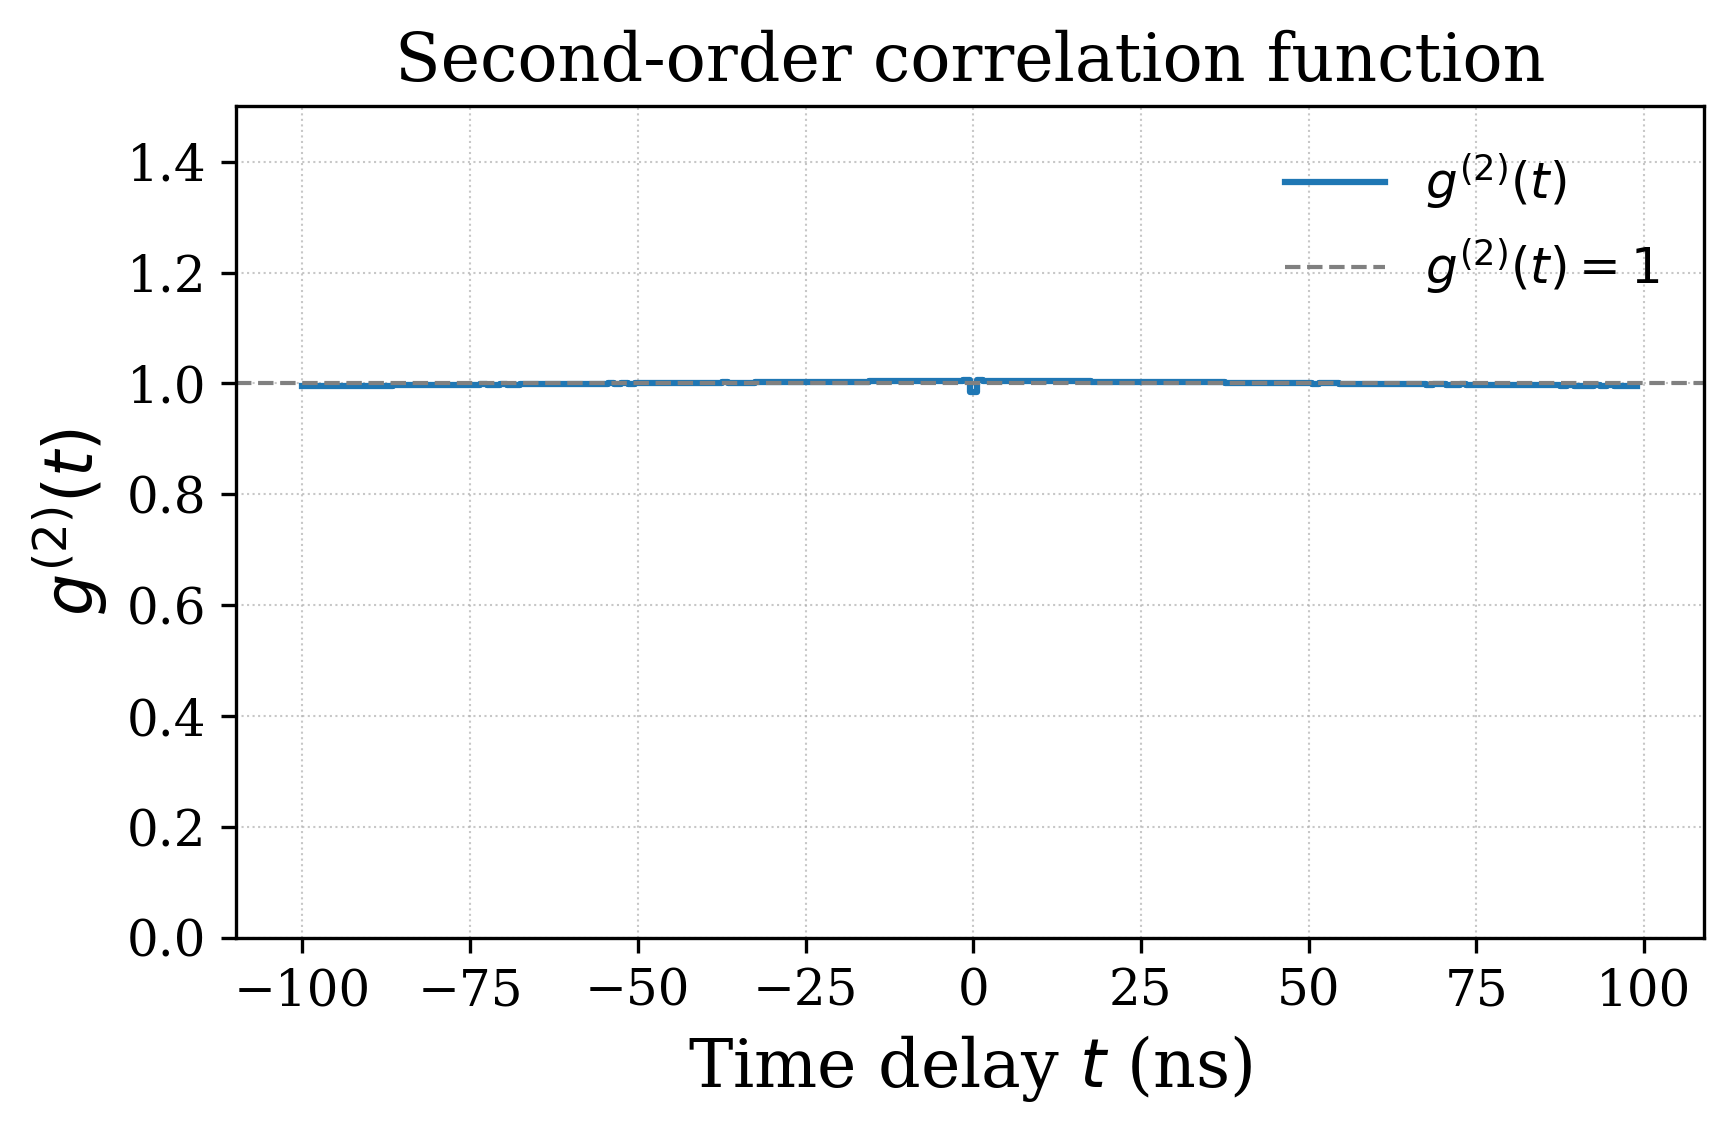

In [47]:
# Example: g2 = counts / denominator, x = time delays (in ns assumed)
# x, g2 already defined
g2 = np.array(counts)/ denominator
# g2 = np.where((g2 >= 0.75) & (g2 <= 1.25), g2, 1)

# Plot settings for paper
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300
})

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))  # Size fits single-column journal

# Plot g2 with step style
ax.plot(x, g2, drawstyle='steps-mid', color='tab:blue', linewidth=1.5, label=r"$g^{(2)}(t)$")

# Horizontal line at g²=1 (uncorrelated photons)
ax.axhline(1, color='gray', linestyle='--', linewidth=1, label=r"$g^{(2)}(t) = 1$")

# Axis labels and title
ax.set_xlabel(r"Time delay $t$ (ns)")
ax.set_ylabel(r"$g^{(2)}(t)$")
ax.set_ylim(0, 1.5)
ax.set_title(r"Second-order correlation function")

# Grid and legend
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(loc='best', frameon=False)

# Tight layout
plt.tight_layout()

# Optional: Save to file (high-res PNG or vector PDF)
# plt.savefig("g2_plot.pdf", format="pdf", bbox_inches="tight")
# plt.savefig("g2_plot.png", dpi=600, bbox_inches="tight")

plt.show()
